# using models trained in the Mycol app

This notebook demonstrates how to use cellpose and densenet models trained in Mycol. For accurate segmentation and classification, it is important that the preprocessing pipelines used within the app are used.

In [40]:
import sys, torch, tifffile, numpy as np, matplotlib.pyplot as plt, matplotlib.patches as mpatches
sys.path.insert(0, "..")

from cellpose import models as cp_models
from src.helpers.cellpose_functions import preprocess_for_cellpose, convert_cellpose_mask_to_single_array
from src.helpers.densenet_functions import get_device, build_densenet, generate_patches_with_ids, patch_to_tensor

# --- paths & config ---
IMAGE_PATH          = "../demo_data/images/demo01.tif"
CELLPOSE_MODEL_PATH = "../demo_data/cellpose_model.pt"
DENSENET_MODEL_PATH = "../demo_data/densenet_demo.pth"
CLASS_NAMES         = ["class_0", "class_1"]   # match training order

In [ ]:
# --- load image ---
raw  = tifffile.imread(IMAGE_PATH)
H, W = raw.shape[:2]
rec  = {"image": raw, "H": H, "W": W}  # record dict used throughout the app

# --- segment ---
cp_model   = cp_models.CellposeModel(pretrained_model=CELLPOSE_MODEL_PATH, gpu=torch.cuda.is_available())
# preprocess_for_cellpose: converts to grayscale and normalises mean intensity
# matching exactly what the app does before running Cellpose
masks_raw, _, _ = cp_model.eval(preprocess_for_cellpose(rec), diameter=0, channels=[0, 0])
# convert_cellpose_mask_to_single_array: remaps instance IDs to a contiguous label image (1..N)
masks      = convert_cellpose_mask_to_single_array(masks_raw, H, W)
rec["masks"] = masks

# --- classify ---
device     = get_device()
# build_densenet: constructs the same DenseNet-121 architecture used during training
# (ImageNet features frozen, two-layer classifier head on top)
dn_model   = build_densenet(num_classes=len(CLASS_NAMES))
dn_model.load_state_dict(torch.load(DENSENET_MODEL_PATH, map_location="cpu", weights_only=True))
dn_model.to(device).eval()

# generate_patches_with_ids: crops a 64×64 region around each cell using its mask
patches, cell_ids = generate_patches_with_ids(rec)
# normalises mean, converts HWC → CHW, and scales pixel values to [0, 1]
X = torch.stack([patch_to_tensor(p) for p in patches]).to(device)
with torch.no_grad():
    preds = torch.argmax(dn_model(X), dim=1).cpu().numpy()

cell_classes = {cid: CLASS_NAMES[idx] for cid, idx in zip(cell_ids, preds)}

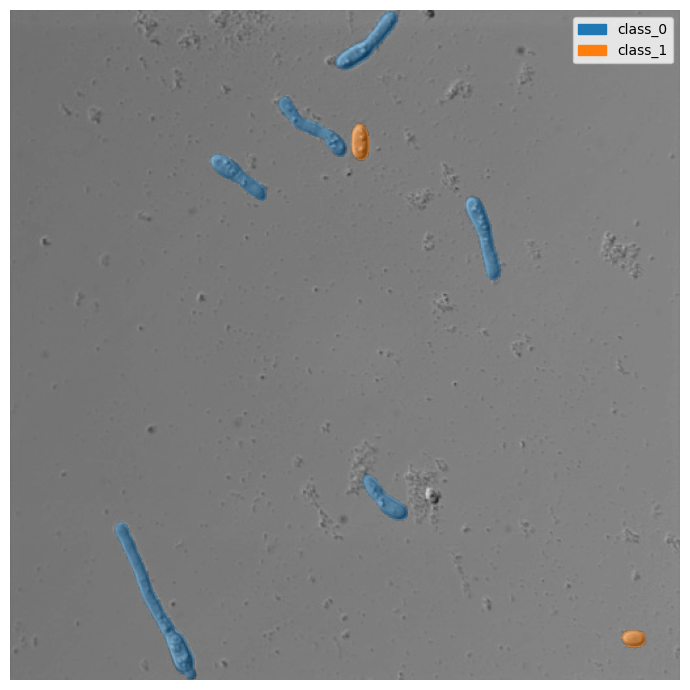

In [42]:
# --- visualise ---
colours = {name: plt.cm.tab10(i) for i, name in enumerate(CLASS_NAMES)}
overlay = np.zeros((H, W, 4), dtype=np.float32)
for cid, cls in cell_classes.items():
    overlay[masks == cid] = colours[cls]

base = raw if raw.ndim == 2 else raw[..., 0]
base = (base.astype(np.float32) - base.min()) / max(base.ptp(), 1)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(base, cmap="gray")
ax.imshow(overlay, alpha=0.5)
ax.legend(handles=[mpatches.Patch(color=c, label=n) for n, c in colours.items()], loc="upper right")
ax.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# show per class cell counts

import pandas as pd

pd.Series(cell_classes.values()).value_counts().rename("count").to_frame().T

,class_0,class_1
count,6,2
